## Exploratory Data Analysis (EDA)

### Step 1: Load and Preview the Dataset

In this step, we load the **Telco Customer Churn dataset** and preview the first few rows to understand the dataset structure and key variables.


In [691]:
# Step 1: Load and preview the dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("raw_dataset.csv")

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Step 2: Data Understanding and Quality Assessment

### 2.1 Dataset Size

In [692]:
# Display the number of rows (customers) and columns (features) in the dataset

print(f"Number of customers: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

Number of customers: 7043
Number of features: 21


**Dataset Size:**

The dataset contains **7,043 customer records** and **21 features**.  
Each row represents a unique customer, while the columns include demographic information, service subscriptions, contract details, and billing information.

**Target Variable:**

The target variable in this dataset is **Churn**, which indicates whether a customer has discontinued the service.


### 2.2 Data Types:

In [693]:
# Display dataset structure, data types, and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Data Types:**

The dataset contains **7,043** records and **21** columns.  
Most features are **categorical** (customer demographics, subscribed services, and billing details).

**Continuous numerical features** include:
- `tenure`
- `MonthlyCharges`

The `SeniorCitizen` feature is stored as an integer, but it represents a **binary categorical indicator** (0 = No, 1 = Yes).

`TotalCharges` appears as an **object** type even though it should be numeric, so it will require type conversion during preprocessing.

The target variable **Churn** is categorical and indicates whether a customer has discontinued the service.

### Note on TotalCharges Data Type 

In [694]:
# Quick check: why TotalCharges is stored as object?
df['TotalCharges'].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [695]:
df['TotalCharges'].apply(lambda x: str(x).strip() == '').sum()


11

This quick inspection shows that the values in the `TotalCharges` column appear
numeric; however, the column is stored as an object data type.

A further check confirms the presence of non-numeric values (specifically,
**11 empty** string entries) within the column, which prevents automatic conversion
to a numerical type.

The actual type conversion and handling of these values will be performed during
the preprocessing stage.

### 2.3 Missing Values

In [696]:
# Check missing values per column
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Missing Values:**

All columns contain complete data with **no** missing values, indicating good data quality.

### 2.4 Duplicate Records

In [697]:
# Check for duplicate rows
df.duplicated().sum()


0

**Duplicate Records:**

The dataset was examined for duplicate records to ensure data integrity.

The result is **0**, meaning **no duplicate records** were found and each row represents a unique customer.



### 2.5 Outlier Detection


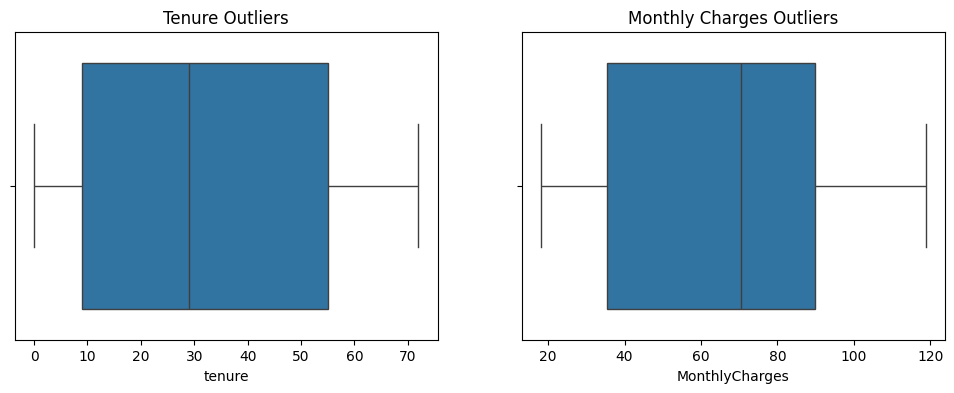

In [698]:
# Boxplot for numerical features
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['tenure'])
plt.title('Tenure Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['MonthlyCharges'])
plt.title('Monthly Charges Outliers')

plt.show()


**Outlier Detection:**

Boxplots were used to examine potential outliers in **continuous numerical features**.

The analysis focused on:
- `tenure`
- `MonthlyCharges`

The `SeniorCitizen` feature was not included in outlier detection because it is a **binary indicator** (0/1), not a continuous variable.

No extreme outliers were observed in `tenure` or `MonthlyCharges`, so no outlier treatment was applied during EDA.




***Observations:***

Based on the data understanding and quality assessment, the dataset is generally
clean, with no missing values or duplicate records.

Some minor preprocessing steps are required, such as:
- Converting `TotalCharges` to a numerical data type
- Encoding categorical variables, including `SeniorCitizen`

These steps will be handled in the data preprocessing stage prior to modeling.

### Step 3: Exploratory Data Analysis (EDA)

## 3.1.Univariate Analysis

**3.1.1 Target Variable Distribution(Churn)**

This section examines the distribution of the target variable **Churn**
to understand the class balance in the dataset.


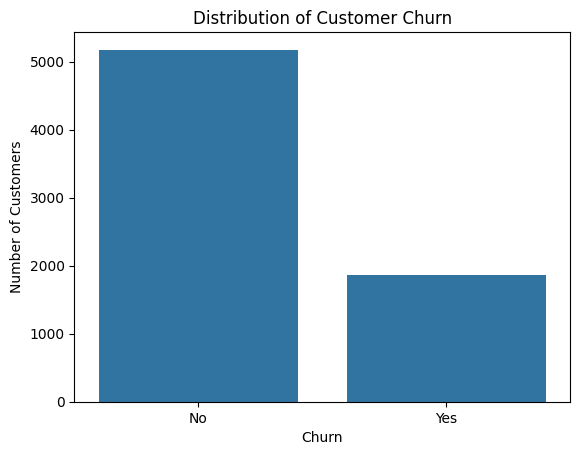

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [699]:
# Distribution of target variable (Churn)
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

# Percentage distribution
df['Churn'].value_counts(normalize=True) * 100



The target variable **Churn** is **imbalanced**, with approximately **73.4%**
of customers not churning and **26.5%** churning.

This class imbalance should be considered during the modeling stage, as it may bias
predictive models toward the majority class and affect overall performance.

**3.1.2 Distribution of Numerical Features**

This section explores the distributions of continuous numerical variables
to understand their spread and skewness.


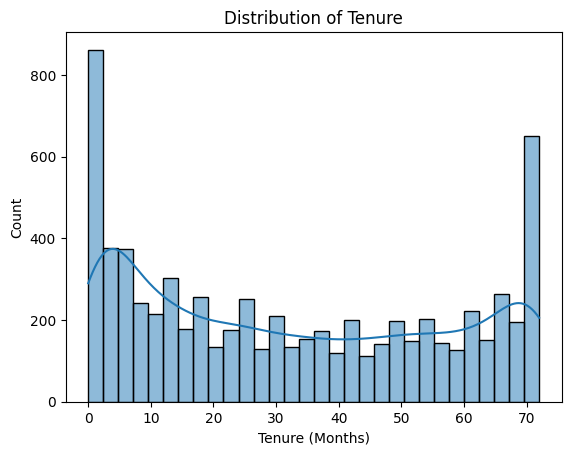

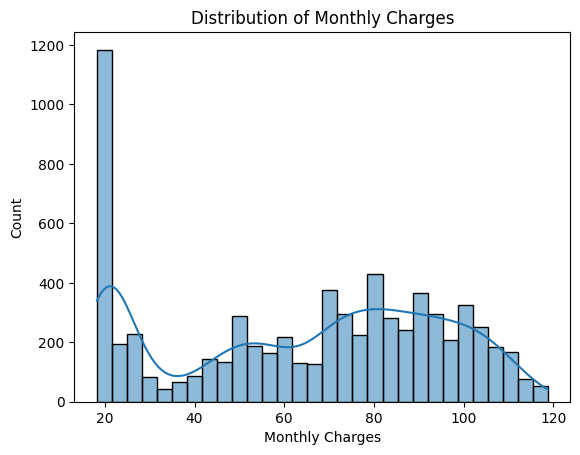

In [700]:
# Distribution of tenure
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title('Distribution of Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()

# Distribution of MonthlyCharges
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.show()


**Tenure** shows a **right-skewed** distribution, with a high concentration of customers
in the early months of service, indicating that many customers are relatively new.
A secondary peak at higher tenure values suggests the presence of long-term loyal customers.

**MonthlyCharges** exhibits a **wide and multi-modal** distribution, reflecting the
diversity of service plans and pricing tiers offered to customers.

## 3.2 Bivariate Analysis (Feature vs Target)

**3.2.1 Categorical Features (Customer Profile & Subscription) vs Churn**

This section analyzes how selected categorical features
relate to customer churn.

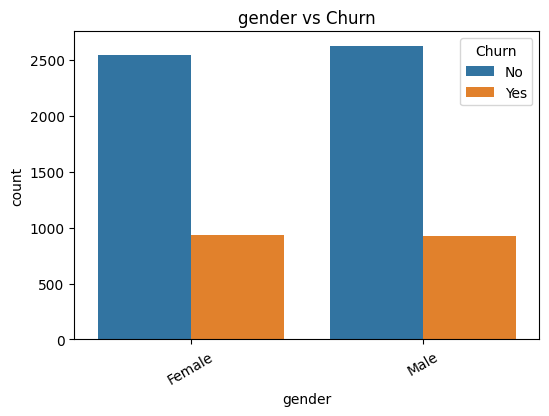

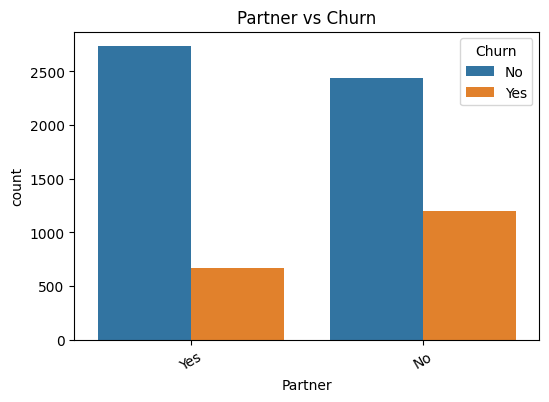

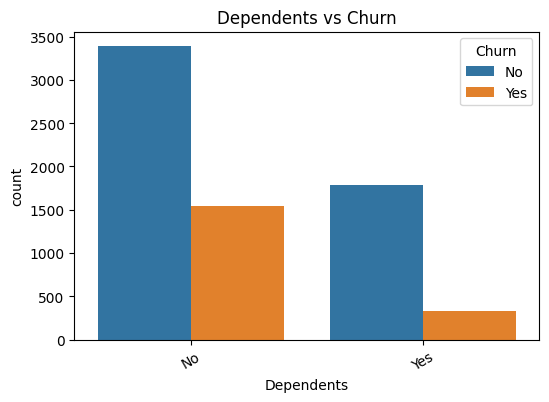

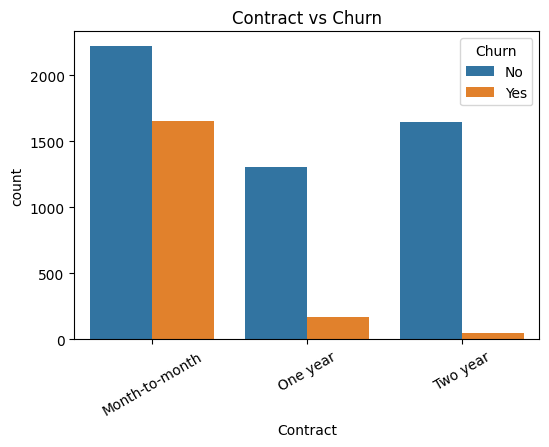

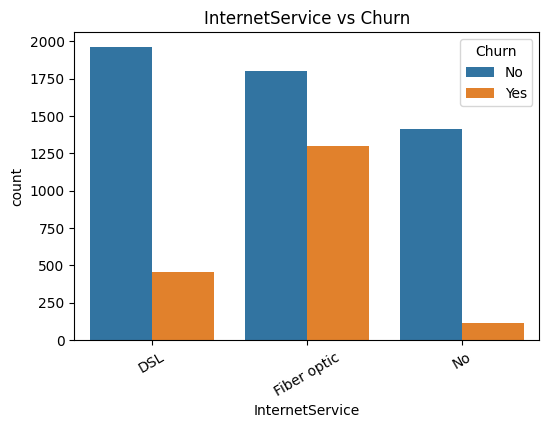

In [701]:
#(Demographic & Subscription Features)
categorical_features = ['gender', 'Partner', 'Dependents', 'Contract', 'InternetService']

for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=30)
    plt.show()


 **Categorical Features (Customer Profile & Subscription) vs Churn — Explanation**

The following categorical features were selected for analysis because they represent key customer demographics, relationship status, and service characteristics, which are commonly associated with customer retention behavior.

***Gender***

The distribution of churn is relatively similar across male and female customers.
This suggests that gender alone does not have a strong influence on churn behavior in this dataset.

***Partner***

Customers without a partner show a noticeably higher proportion of churn compared to those with a partner.
This may indicate that customers with partners are more stable or more likely to retain bundled or long-term services.

***Dependents***

Customers without dependents exhibit significantly higher churn rates.
Having dependents may increase service dependency, leading to lower churn likelihood.

***Contract***

This feature shows one of the strongest relationships with churn:

Customers on month-to-month contracts have the highest churn rate.

Customers with one-year or two-year contracts are much less likely to churn.

This indicates that longer contract commitments strongly reduce churn risk.

***InternetService***

Churn behavior varies noticeably by internet service type:

Fiber optic customers show higher churn compared to DSL users.

Customers with no internet service have the lowest churn.

This suggests that service type and pricing complexity may influence customer satisfaction and retention.

**Overall Insight**

Among the analyzed categorical features, Contract, Dependents, and InternetService demonstrate the strongest association with churn behavior.

These features are likely to be important predictors and will be further validated during the modeling stage to assess their predictive power.

**3.2.2 Categorical Features (Support & Add-on Services) vs Churn**


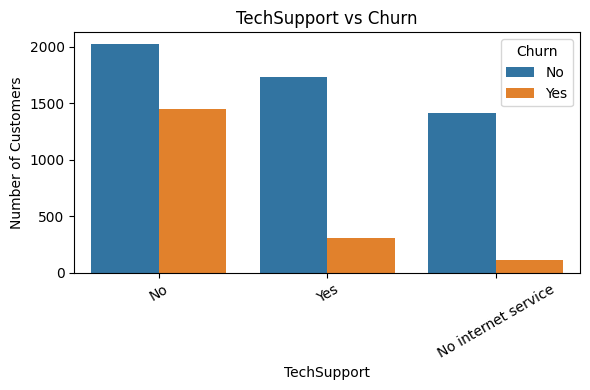

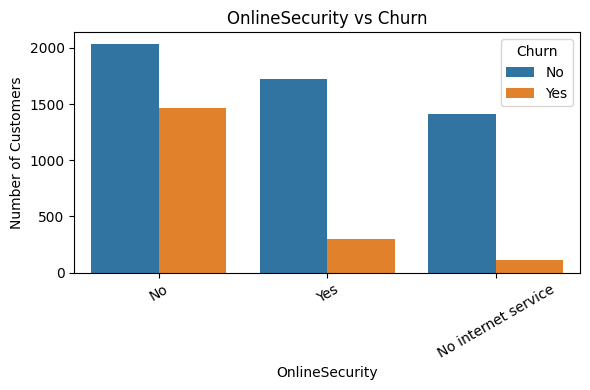

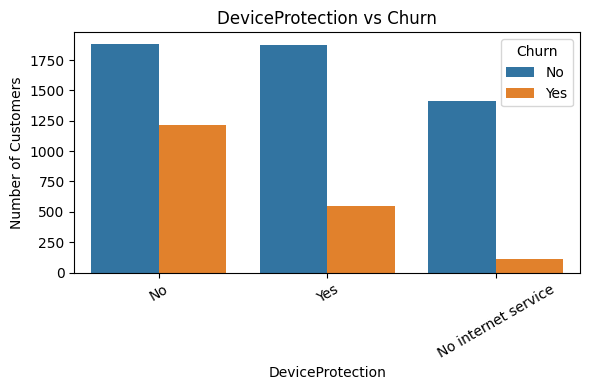

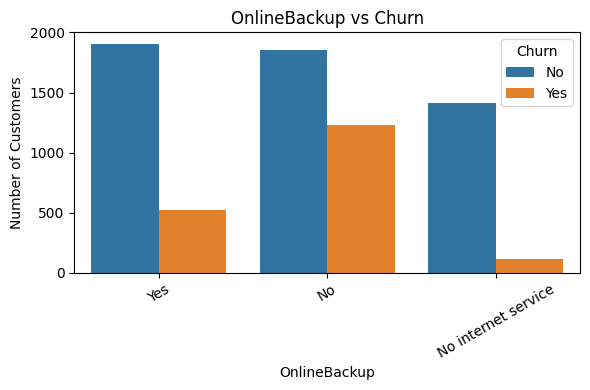

In [702]:
#(Service Quality & Add-ons)
support_features = [
    'TechSupport',
    'OnlineSecurity',
    'DeviceProtection',
    'OnlineBackup'
]

for col in support_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f'{col} vs Churn')
    plt.xlabel(col)
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


**Categorical Features (Support & Add-on Services) vs Churn — Explanation**

***TechSupport***

Customers without technical support show a significantly higher churn rate compared to those who have access to technical support.

This indicates that the availability of technical assistance plays an important role in customer retention, as customers may rely on support services to resolve issues and maintain satisfaction.

***OnlineSecurity***

Customers who do not subscribe to online security services are more likely to churn than those who do.

This suggests that security-related services increase customer trust and enhance the perceived value of the service, reducing the likelihood of churn.

***DeviceProtection***

Churn is noticeably higher among customers without device protection, while customers who subscribe to device protection services show lower churn rates.

This highlights the importance of add-on protection services in strengthening customer loyalty and reducing dissatisfaction related to device issues.

***OnlineBackup***

Customers without online backup services exhibit a higher churn rate compared to those who use online backup.

Providing backup services may increase perceived service reliability and reduce customer concerns about data loss, contributing to improved retention.

**Overall Insight**

Support and add-on service features show a strong association with customer churn.

Customers who subscribe to technical support and additional protection services are generally less likely to churn, highlighting the importance of service quality, security, and post-subscription support in customer retention.

These features are therefore considered relevant candidates for inclusion in the modeling stage.

**Observations:**

**"No internet service"** represents customers who do not have internet access and are therefore not eligible for support or add-on services.
This category is distinct from customers who actively chose not to subscribe to these services.

**3.2.3 Numerical Features vs Churn**

This section compares numerical features across churn categories.

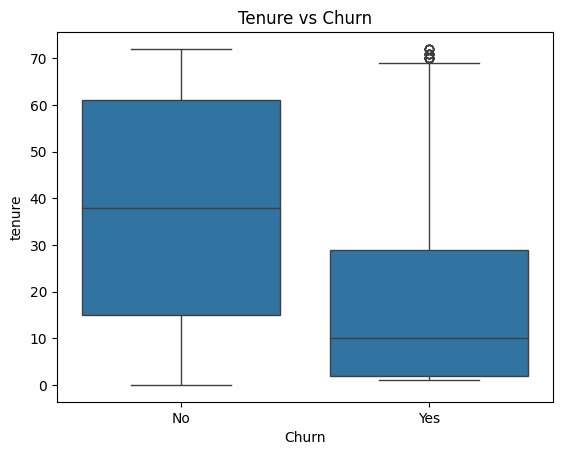

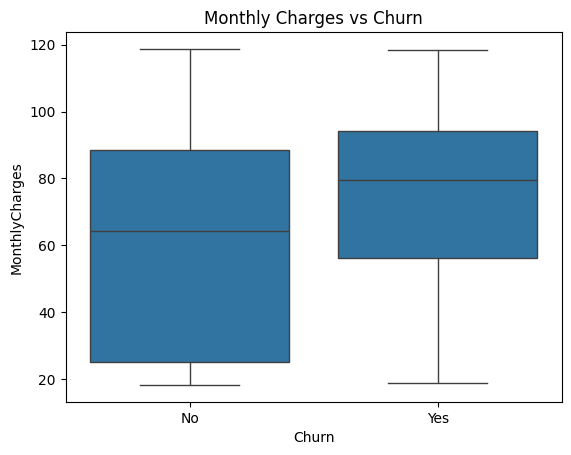

In [703]:
# Tenure vs Churn
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

# MonthlyCharges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()


**Tenure vs Churn**

Customers who churn tend to have significantly shorter tenure compared to non-churned customers.

The median tenure of churned customers is substantially lower, indicating that churn is more likely to occur during the early stages of the customer lifecycle.

This suggests that retention strategies should particularly focus on new and early-stage customers to reduce churn.

**Monthly Charges vs Churn**

Churned customers generally exhibit higher monthly charges compared to customers who remain.

The higher median monthly charge among churned customers suggests that pricing and perceived value may contribute to dissatisfaction and increase the likelihood of churn.

**Overall Insight**

The bivariate analysis of numerical features indicates that customers with shorter tenure and higher monthly charges are more prone to churn.

These findings highlight the importance of customer lifecycle stage and pricing structure as key drivers of churn behavior. Both features are therefore expected to play a significant role in the predictive modeling phase.

**3.2.4 Contract vs Churn (Churn Rate)**

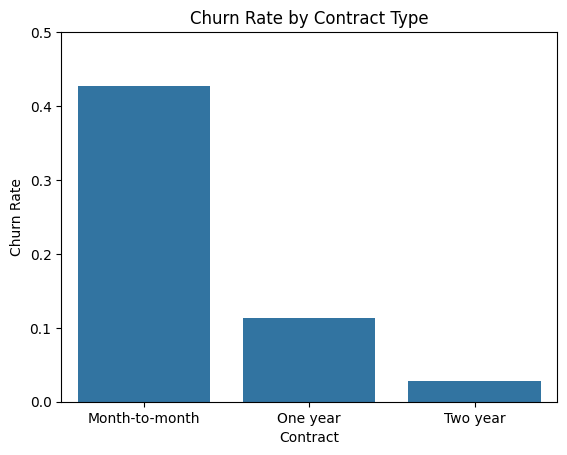

In [704]:
churn_rate = (
    df.groupby('Contract')['Churn']
      .value_counts(normalize=True)
      .rename('proportion')
      .reset_index()
)

sns.barplot(
    data=churn_rate[churn_rate['Churn'] == 'Yes'],
    x='Contract',
    y='proportion'
)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.ylim(0, 0.5)
plt.show()

This bar chart presents the churn rate across different contract types, allowing for a normalized comparison of customer churn behavior.

Customers with **month-to-month contracts** exhibit the highest churn rate.
The churn rate decreases substantially for **one-year contracts** and is lowest among customers with **two-year contracts**, indicating stronger customer retention as contract duration increases.

This suggests that contract length is a key factor influencing churn behavior.
The observed relationship will be further examined during the modeling stage to assess its predictive impact in combination with other features.

## 3.3 Multivariate Analysis

**3.3.1 Multivariate Analysis:  Monthly Charges, Contract, and Churn**
 
Impact of Monthly Charges and Contract Type on Churn

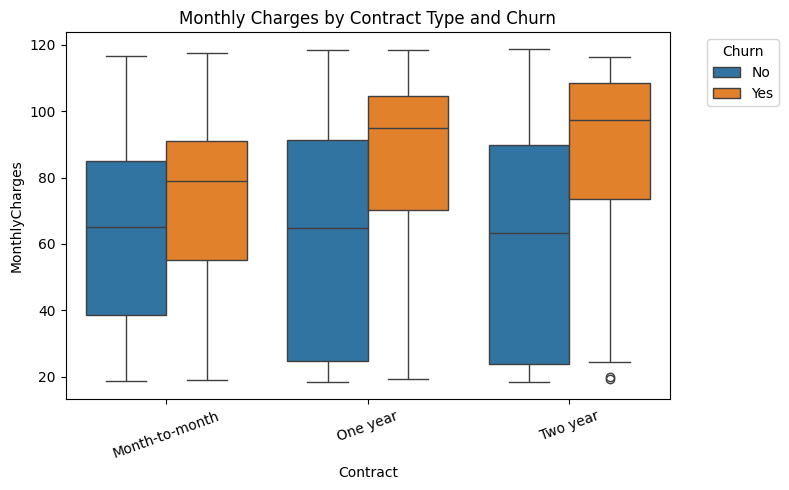

In [705]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x='Contract',
    y='MonthlyCharges',
    hue='Churn',
    data=df
)

plt.title('Monthly Charges by Contract Type and Churn')
plt.xticks(rotation=20)

# Move legend outside the plot
ax.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()



This visualization illustrates how customer churn is influenced by the interaction
between contract type and monthly charges.

Across all contract types, customers who churn tend to have higher monthly charges
compared to those who remain, indicating that pricing plays a significant role in
churn behavior.

The interaction effect is most pronounced for **month-to-month contracts**, where churned
customers show notably higher monthly charges. 
In contrast, customers with **one-year** and **two-year contracts** exhibit lower churn rates even at higher price levels.

This suggests that long-term contracts help mitigate the impact of high monthly charges
on churn, highlighting the combined effect of pricing and contract duration as key drivers of customer retention.




**3.3.2 Multivariate Analysis: Tenure, Contract, and Churn**

Impact of Tenure and Contract Type on Churn

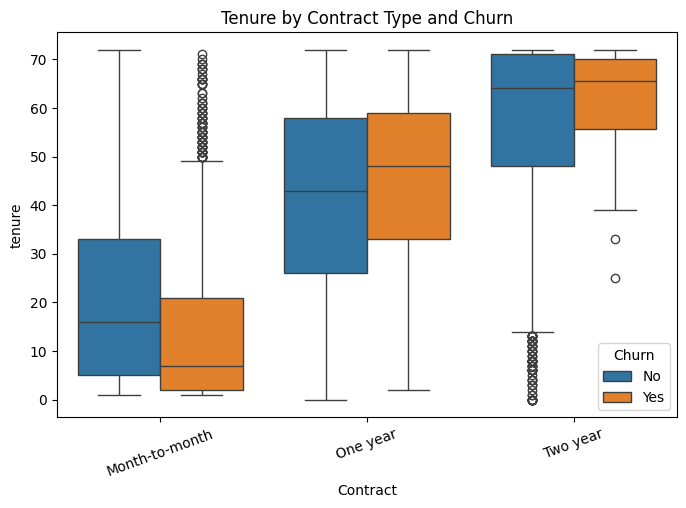

In [706]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Contract', y='tenure', hue='Churn', data=df)
plt.title('Tenure by Contract Type and Churn')
plt.xticks(rotation=20)
plt.show()


This boxplot illustrates the relationship between customer tenure, contract type,
and churn behavior, highlighting how contract duration interacts with customer
retention over time.

Customers on **month-to-month contracts** exhibit the shortest tenure, particularly
among churned customers. This indicates that churn is most likely to occur during
the early stages of the customer lifecycle when commitment is minimal.

For **one-year contracts**, customers generally show longer tenure compared to
month-to-month plans. However, churn still occurs, often before completing the
full contract period.

Customers with **two-year contracts** demonstrate the highest tenure and the lowest
churn levels. Churned customers in this group tend to have significantly longer
tenure, reflecting stronger long-term engagement and loyalty.

Overall, this analysis reveals that **longer contract durations are associated with greater customer stability**, while shorter contracts increase the likelihood of
early churn. These findings highlight the importance of contract structure in
shaping customer retention behavior.


## EDA Summary and Conclusion

This exploratory data analysis examined customer churn patterns across demographic, subscription, service, and pricing features using univariate, bivariate, and multivariate analysis.

The analysis identified contract type, tenure, monthly charges, and service add-ons as the most influential factors associated with churn. Customers on short-term contracts, with shorter tenure and higher monthly charges, were more likely to churn, while long-term contracts and value-added services were associated with stronger customer retention.

These insights provide a solid foundation for the subsequent data preprocessing and modeling stage, where the identified relationships will be quantitatively evaluated for their predictive power.